In [1]:
# Environment setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import io
import warnings
from linearmodels.panel import PanelOLS

warnings.filterwarnings('ignore')

print("Working directory:", os.getcwd())
print("\nFiles visible:")
for f in sorted(os.listdir('.')):
    if f.endswith(('.csv', '.xlsx')):
        print(" ", f)

Working directory: C:\Users\Ashutosh\anaconda_projects\3ff2dc91-f47a-4513-9642-b532def3bf76

Files visible:
  RBI_Credit.xlsx
  RS_Session_260_AU_194_A_to_B_ii.csv
  RS_Session_260_AU_194_A_to_B_iii.csv
  RS_Session_260_AU_194_A_to_B_iv.csv
  RS_Session_260_AU_194_A_to_B_v.csv
  RS_Session_260_AU_194_A_to_B_vi.csv
  RS_Session_260_AU_194_A_to_B_vii.csv
  cvi_scores - Sheet1.csv


In [2]:
# Load and clean RBI Table 157 agricultural credit data.
# Reshapes wide (state x year) format into a long state-year panel.

credit_raw = pd.read_excel('RBI_Credit.xlsx', sheet_name=0)
print("RBI raw shape:", credit_raw.shape)
print("RBI columns:", credit_raw.columns.tolist())

# Drop the North-Eastern subtotal row and Daman (merged into
# Dadra & Nagar Haveli in 2020, creating an inconsistent series).
rows_to_drop = ['NORTH-EASTERN', 'Daman']
credit_raw = credit_raw[~credit_raw.iloc[:, 0].isin(rows_to_drop)].copy()
print("After dropping regional rows:", credit_raw.shape)

first_col = credit_raw.columns[0]
credit_raw = credit_raw.rename(columns={first_col: 'State'})

# Keep 2016-2022 (2016 retained for context; PMFBY data spans 2017-2022).
year_columns = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
existing = credit_raw.columns.tolist()
year_cols = year_columns if 2016 in existing else [str(y) for y in year_columns]
credit_raw = credit_raw[['State'] + year_cols].copy()
print("After keeping 2016-2022:", credit_raw.shape)

# Clean Indian number formatting, e.g. "1,04,797" -> 104797.
for col in year_cols:
    credit_raw[col] = (
        credit_raw[col]
        .astype(str)
        .str.strip()
        .str.replace(',', '', regex=False)
        .replace(['-', 'nan', 'NaN', ''], np.nan)
        .pipe(pd.to_numeric, errors='coerce')
    )

# Reshape wide -> long: one row per state-year.
credit_long = pd.melt(
    credit_raw, id_vars=['State'], value_vars=year_cols,
    var_name='Year', value_name='Credit_Crore'
)
credit_long['Year'] = credit_long['Year'].astype(int)
credit_long['State'] = credit_long['State'].str.strip()
credit_long = credit_long.sort_values(['State', 'Year']).reset_index(drop=True)

# Policy dummy: 0 = compulsory loanee enrollment, 1 = voluntary
# enrollment for all farmers (from Kharif 2020 onward).
credit_long['post_2020'] = np.where(credit_long['Year'] >= 2020, 1, 0)

print("\nCredit panel shape:", credit_long.shape)
print("Expected: ~252 rows (36 states x 7 years)")
print("\nSample - Bihar:")
print(credit_long[credit_long['State'] == 'Bihar'])

RBI raw shape: (38, 12)
RBI columns: ['Region/State/Union', 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
After dropping regional rows: (36, 12)
After keeping 2016-2022: (36, 8)

Credit panel shape: (252, 4)
Expected: ~252 rows (36 states × 7 years)

Sample — Bihar (verify years and values look right):
    State  Year  Credit_Crore  post_2020
28  Bihar  2016       30167.0          0
29  Bihar  2017       34436.0          0
30  Bihar  2018       35561.0          0
31  Bihar  2019       39598.0          0
32  Bihar  2020       43460.0          1
33  Bihar  2021       49605.0          1
34  Bihar  2022       54380.0          1


In [3]:
# Load and stack the six PMFBY (Rajya Sabha) year files.
# Premium/claims column names carry a year suffix that changes
# each file, so columns are located by keyword rather than hardcoded.

pmfby_file_year_map = {
    'RS_Session_260_AU_194_A_to_B_ii.csv':   2017,
    'RS_Session_260_AU_194_A_to_B_iii.csv':  2018,
    'RS_Session_260_AU_194_A_to_B_iv.csv':   2019,
    'RS_Session_260_AU_194_A_to_B_v.csv':    2020,
    'RS_Session_260_AU_194_A_to_B_vi.csv':   2021,
    'RS_Session_260_AU_194_A_to_B_vii.csv':  2022,
}

pmfby_frames = []
for filename, year in pmfby_file_year_map.items():
    df = pd.read_csv(filename)
    premium_col = [c for c in df.columns if 'Gross Premium' in c][0]
    claims_col = [c for c in df.columns if 'Paid Claims' in c][0]
    df = df.rename(columns={
        premium_col: 'Premium_Crore',
        claims_col:  'Claims_Crore',
        'State/UT':  'State'
    })
    df = df[['State', 'Company', 'Premium_Crore', 'Claims_Crore']].copy()
    df['Year'] = year
    df['State'] = df['State'].str.strip()
    pmfby_frames.append(df)
    print(f"Loaded {filename} -> Year {year} | Shape: {df.shape}")

pmfby_raw = pd.concat(pmfby_frames, ignore_index=True)
print("\nPMFBY combined shape:", pmfby_raw.shape)
print("Years:", sorted(pmfby_raw['Year'].unique()))
print(pmfby_raw.head(6))

Loaded RS_Session_260_AU_194_A_to_B_ii.csv → Year 2017 | Shape: (98, 5)
Loaded RS_Session_260_AU_194_A_to_B_iii.csv → Year 2018 | Shape: (101, 5)
Loaded RS_Session_260_AU_194_A_to_B_iv.csv → Year 2019 | Shape: (78, 5)
Loaded RS_Session_260_AU_194_A_to_B_v.csv → Year 2020 | Shape: (54, 5)
Loaded RS_Session_260_AU_194_A_to_B_vi.csv → Year 2021 | Shape: (57, 5)
Loaded RS_Session_260_AU_194_A_to_B_vii.csv → Year 2022 | Shape: (63, 5)

PMFBY combined shape: (451, 5)
Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
                        State        Company  Premium_Crore  Claims_Crore  \
0  Andaman and Nicobar Island       National           0.03          0.00   
1              Andhra Pradesh            AIC         214.18         74.64   
2              Andhra Pradesh      HDFC Ergo         723.90        296.57   
3              Andhra Pradesh  ICICI Lombard         205.08        163.95   
4              Andhra Pradesh    IFFCO Tokio 

In [4]:
# Aggregate PMFBY to one row per state-year (sum across insurers).

pmfby_agg = (
    pmfby_raw
    .groupby(['State', 'Year'], as_index=False)
    [['Premium_Crore', 'Claims_Crore']]
    .sum()
)

# Claims-to-premium ratio: > 1 means the insurer paid out
# more than it collected in that state-year.
pmfby_agg['Claims_Premium_Ratio'] = (
    pmfby_agg['Claims_Crore'] / pmfby_agg['Premium_Crore']
).round(3)

print("PMFBY aggregated:", pmfby_agg.shape)
print(pmfby_agg[pmfby_agg['State'].str.contains('Maharashtra', na=False)])

PMFBY aggregated: (144, 5)
One row per state per year:
          State  Year  Premium_Crore  Claims_Crore  Claims_Premium_Ratio
69  Maharashtra  2017        4136.27       3315.69                 0.802
70  Maharashtra  2018        6118.79       6144.14                 1.004
71  Maharashtra  2019        6354.52       6758.33                 1.064
72  Maharashtra  2020        6495.22       1319.98                 0.203
73  Maharashtra  2021        5903.10       4373.99                 0.741
74  Maharashtra  2022        5308.58       2614.23                 0.492


In [5]:
# Standardise state names before merging.
# RBI uses abbreviated names; PMFBY uses full names, and pd.merge()
# needs exact string matches, so known mismatches are mapped explicitly.

state_name_map = {
    'Himachal':      'Himachal Pradesh',
    'Jammu':         'Jammu & Kashmir',
    'Madhya':        'Madhya Pradesh',
    'Andhra':        'Andhra Pradesh',
    'Andaman':       'Andaman and Nicobar Island',
    'Dadra':         'Dadra & Nagar Haveli',
}

credit_long['State'] = credit_long['State'].replace(state_name_map).str.strip()

credit_states = set(credit_long['State'].unique())
pmfby_states  = set(pmfby_agg['State'].unique())
only_in_credit = credit_states - pmfby_states
only_in_pmfby  = pmfby_states  - credit_states

print("In credit but NOT in PMFBY (will be dropped):")
for s in sorted(only_in_credit):
    print(" ", s)

print("\nIn PMFBY but NOT in credit (will be dropped):")
for s in sorted(only_in_pmfby):
    print(" ", s)

print("\nMatched states:", len(credit_states & pmfby_states))

In credit but NOT in PMFBY (will be dropped):
  Arunachal
  Chandigarh
  Dadra & Nagar Haveli
  Delhi
  Jammu & Kashmir
  Ladakh
  Lakshadweep
  Mizoram
  Nagaland
  Punjab

In PMFBY but NOT in credit (will be dropped):
  Jammu and Kashmir
  Total

Matched states: 26


In [9]:
# Load the CEEW Climate Vulnerability Index.
# One score per state; no year dimension, so it is applied
# uniformly across all panel years for a given state.

cvi = pd.read_csv('cvi_scores - Sheet1.csv')
print("CVI raw shape:", cvi.shape)
print("CVI columns:", cvi.columns.tolist())

cvi = cvi.rename(columns={'Overall Vulnerability Index': 'CVI_Score'})
cvi = cvi[['State', 'CVI_Score']]
cvi['State'] = cvi['State'].str.strip()

print("\nCVI after cleaning:")
print(cvi.head(28))

CVI raw shape: (35, 3)
CVI columns: ['Rank', 'State', 'Overall Vulnerability Index']

CVI after cleaning:
                          State  CVI_Score
0                         Assam      0.616
1                Andhra Pradesh      0.483
2                   Maharashtra      0.478
3                     Karnataka      0.465
4                         Bihar      0.448
5                       Manipur      0.424
6                     Rajasthan      0.423
7             Arunachal Pradesh      0.408
8                        Sikkim      0.370
9                        Odisha      0.368
10                     Nagaland      0.365
11                   Tamil Nadu      0.339
12             Himachal Pradesh      0.329
13            Jammu and Kashmir      0.328
14                    NCT Delhi      0.290
15                      Gujarat      0.280
16                Uttar Pradesh      0.269
17                  West Bengal      0.257
18                      Tripura      0.250
19                       Kerala   

In [10]:
# Merge credit, PMFBY, and CVI into a single panel.
# Step 1: credit + PMFBY on (State, Year), inner join.
# Step 2: + CVI on State only, left join (CVI has no year axis).

panel = pd.merge(
    credit_long, pmfby_agg, on=['State', 'Year'], how='inner'
)
print("After credit + PMFBY merge:", panel.shape)

panel = pd.merge(panel, cvi, on='State', how='left')
print("After adding CVI:", panel.shape)
print("\nFinal columns:", panel.columns.tolist())
print("\nSample:")
print(panel.head(10))

After credit + PMFBY merge: (134, 7)
After adding CVI: (134, 8)

Final columns: ['State', 'Year', 'Credit_Crore', 'post_2020', 'Premium_Crore', 'Claims_Crore', 'Claims_Premium_Ratio', 'CVI_Score']

Sample:
                        State  Year  Credit_Crore  post_2020  Premium_Crore  \
0  Andaman and Nicobar Island  2017          91.0          0           0.03   
1  Andaman and Nicobar Island  2018          94.0          0           0.24   
2  Andaman and Nicobar Island  2019         126.0          0           0.03   
3  Andaman and Nicobar Island  2020         132.0          1           0.16   
4  Andaman and Nicobar Island  2021         145.0          1           0.23   
5  Andaman and Nicobar Island  2022         355.0          1           0.03   
6              Andhra Pradesh  2017       89795.0          0        1272.07   
7              Andhra Pradesh  2018      106023.0          0        1437.99   
8              Andhra Pradesh  2019      123985.0          0        1474.73   
9   

In [11]:
# Data quality checks before any modelling.

print("=== MISSING VALUES ===")
print(panel.isnull().sum())

print("\n=== PANEL BALANCE ===")
rows_per_state = panel.groupby('State').size()
print(rows_per_state)
print("Balanced:", (rows_per_state == rows_per_state.max()).all())

print("\n=== SUMMARY STATISTICS ===")
print(panel[['Credit_Crore', 'Premium_Crore',
             'Claims_Crore',
             'Claims_Premium_Ratio']].describe().round(2))

print("\n=== POLICY ERA SPLIT ===")
print(panel.groupby('post_2020').size())
print("  0 = compulsory era (years before 2020)")
print("  1 = voluntary era  (2020 onward)")

panel.to_csv('panel_final.csv', index=False)
print("\nSaved: panel_final.csv")
print("Final shape:", panel.shape)

=== MISSING VALUES ===
State                   0
Year                    0
Credit_Crore            0
post_2020               0
Premium_Crore           0
Claims_Crore            0
Claims_Premium_Ratio    2
CVI_Score               9
dtype: int64

=== PANEL BALANCE ===
State
Andaman and Nicobar Island    6
Andhra Pradesh                4
Assam                         6
Bihar                         1
Chhattisgarh                  6
Goa                           6
Gujarat                       3
Haryana                       6
Himachal Pradesh              6
Jharkhand                     3
Karnataka                     6
Kerala                        6
Madhya Pradesh                6
Maharashtra                   6
Manipur                       6
Meghalaya                     5
Odisha                        6
Puducherry                    5
Rajasthan                     6
Sikkim                        6
Tamil Nadu                    6
Telangana                     3
Tripura                

In [12]:
# Add log-transformed variables.
# Credit and premium values span several orders of magnitude
# across states; logging compresses the range so coefficients
# reflect proportional (%) rather than absolute rupee changes.

panel['log_Credit']  = np.log1p(panel['Credit_Crore'])
panel['log_Premium'] = np.log1p(panel['Premium_Crore'])
panel['log_Claims']  = np.log1p(panel['Claims_Crore'])

print("Log variables added. Comparison:")
print(panel[['Credit_Crore', 'log_Credit',
             'Premium_Crore', 'log_Premium']].head(8))

Log variables added. Comparison:
   Credit_Crore  log_Credit  Premium_Crore  log_Premium
0          91.0    4.521789           0.03     0.029559
1          94.0    4.553877           0.24     0.215111
2         126.0    4.844187           0.03     0.029559
3         132.0    4.890349           0.16     0.148420
4         145.0    4.983607           0.23     0.207014
5         355.0    5.874931           0.03     0.029559
6       89795.0   11.405296        1272.07     7.149187
7      106023.0   11.571421        1437.99     7.271697


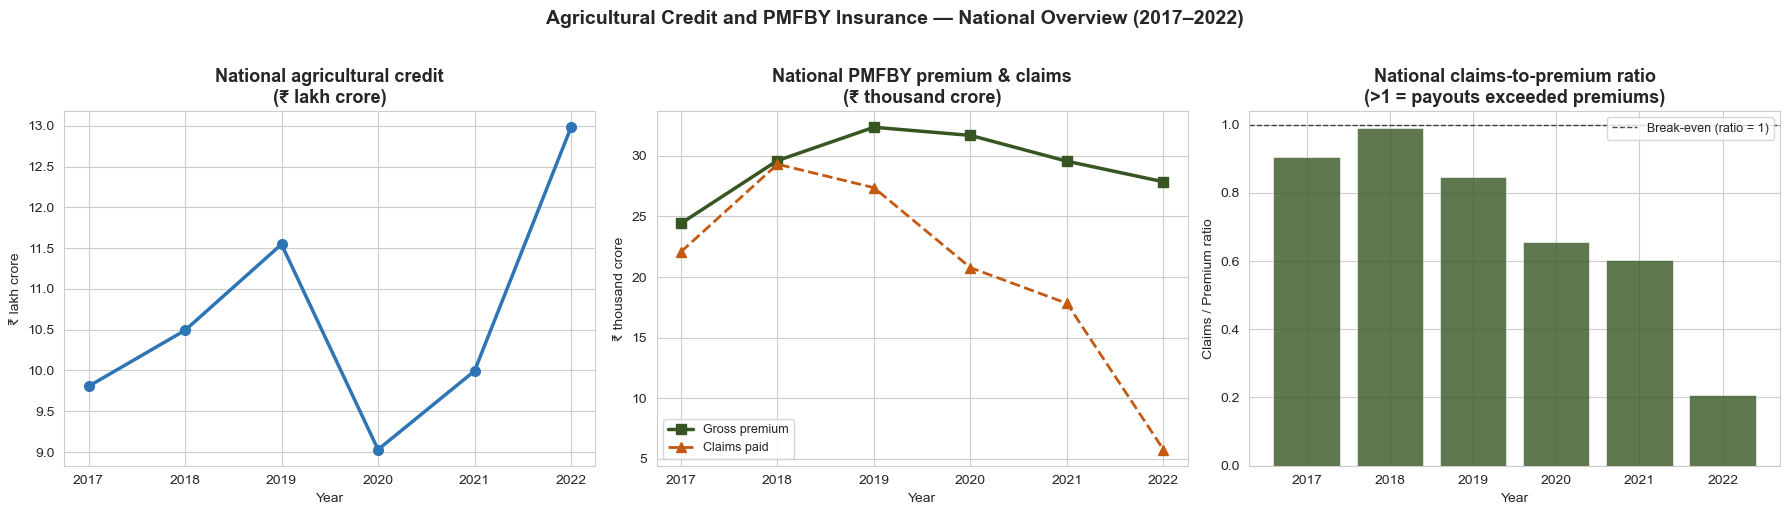

Saved: chart1_national_trends.png


In [13]:
# Descriptive analysis: national time trends.

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

national = panel.groupby('Year')[
    ['Credit_Crore', 'Premium_Crore', 'Claims_Crore']
].sum().reset_index()

# Chart 1: national credit trend.
axes[0].plot(national['Year'], national['Credit_Crore'] / 1e5,
             marker='o', color='#2E75B6', linewidth=2.5, markersize=7)
axes[0].set_title('National agricultural credit\n(₹ lakh crore)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('₹ lakh crore')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Chart 2: premium vs claims trend.
axes[1].plot(national['Year'], national['Premium_Crore'] / 1e3,
             marker='s', color='#375623', linewidth=2.5, markersize=7,
             label='Gross premium')
axes[1].plot(national['Year'], national['Claims_Crore'] / 1e3,
             marker='^', color='#C45911', linewidth=2, markersize=7,
             linestyle='--', label='Claims paid')
axes[1].set_title('National PMFBY premium & claims\n(₹ thousand crore)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('₹ thousand crore')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Chart 3: national claims-to-premium ratio (>1 = payouts exceeded premiums).
national['CPR'] = national['Claims_Crore'] / national['Premium_Crore']
axes[2].bar(
    national['Year'], national['CPR'],
    color=['#C45911' if v > 1 else '#375623' for v in national['CPR']],
    alpha=0.8, edgecolor='white', linewidth=0.5
)
axes[2].axhline(y=1.0, color='black', linestyle='--', linewidth=1,
                alpha=0.7, label='Break-even (ratio = 1)')
axes[2].set_title(
    'National claims-to-premium ratio\n(>1 = payouts exceeded premiums)',
    fontsize=13, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Claims / Premium ratio')
axes[2].legend(fontsize=9)
axes[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Agricultural Credit and PMFBY Insurance — National Overview (2017–2022)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_national_trends.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart1_national_trends.png")

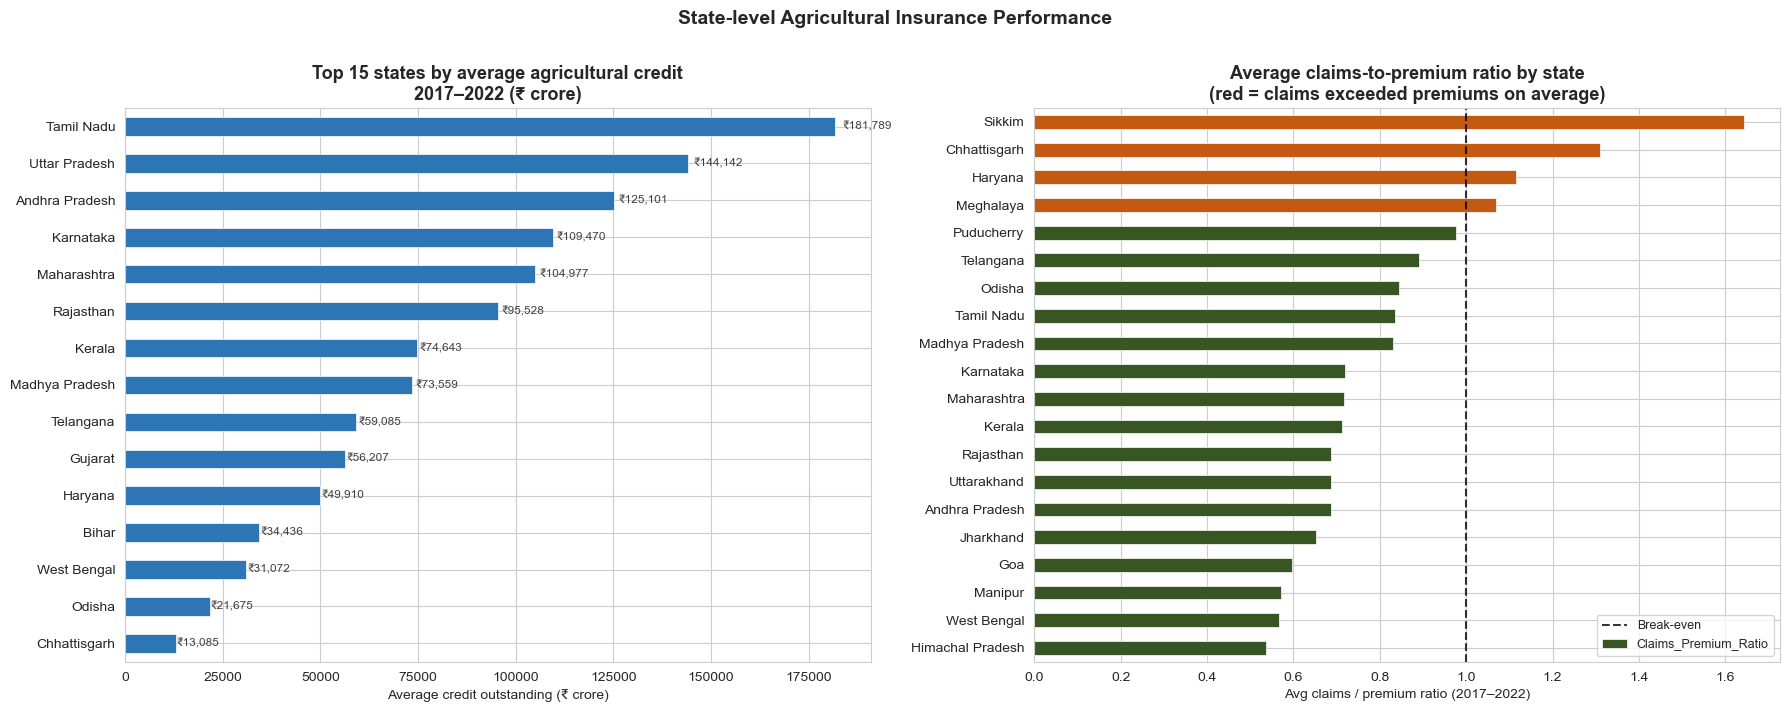

Saved: chart2_state_comparisons.png


In [14]:
# Descriptive analysis: state comparisons.

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 15 states by average credit.
avg_credit = (panel.groupby('State')['Credit_Crore']
              .mean().sort_values(ascending=True).tail(15))
avg_credit.plot(kind='barh', ax=axes[0], color='#2E75B6',
                edgecolor='white', linewidth=0.5)
axes[0].set_title(
    'Top 15 states by average agricultural credit\n2017–2022 (₹ crore)',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average credit outstanding (₹ crore)')
axes[0].set_ylabel('')
for i, (val, name) in enumerate(zip(avg_credit.values, avg_credit.index)):
    axes[0].text(val * 1.01, i, f'₹{val:,.0f}', va='center',
                 fontsize=8.5, color='#404040')

# Claims-to-premium ratio by state (red = claims exceeded premiums on average).
avg_cpr = (panel.groupby('State')['Claims_Premium_Ratio']
           .mean().sort_values(ascending=True).tail(20))
colors_cpr = ['#C45911' if v > 1 else '#375623' for v in avg_cpr.values]
avg_cpr.plot(kind='barh', ax=axes[1], color=colors_cpr,
             edgecolor='white', linewidth=0.5)
axes[1].axvline(x=1.0, color='black', linestyle='--', linewidth=1.5,
                alpha=0.8, label='Break-even')
axes[1].set_title(
    'Average claims-to-premium ratio by state\n(red = claims exceeded premiums on average)',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg claims / premium ratio (2017–2022)')
axes[1].set_ylabel('')
axes[1].legend(fontsize=9)

plt.suptitle('State-level Agricultural Insurance Performance',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart2_state_comparisons.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart2_state_comparisons.png")

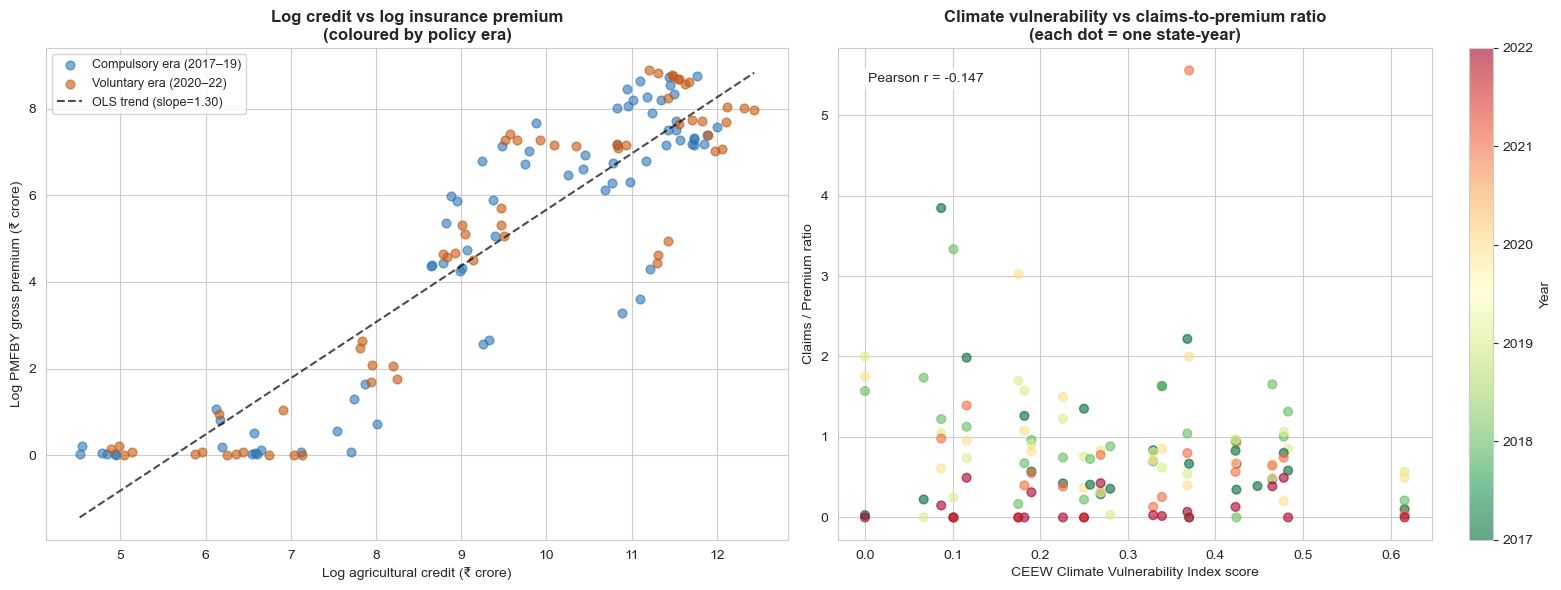

Saved: chart3_scatter_relationships.png


In [15]:
# Descriptive analysis: raw credit-insurance relationship,
# checked visually before any formal regression.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log credit vs log premium, by policy era.
for era, grp in panel.groupby('post_2020'):
    label = ('Voluntary era (2020–22)' if era == 1
             else 'Compulsory era (2017–19)')
    color = '#C45911' if era == 1 else '#2E75B6'
    axes[0].scatter(grp['log_Credit'], grp['log_Premium'],
                    alpha=0.6, s=40, label=label, color=color)

x = panel['log_Credit']
y = panel['log_Premium']
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
axes[0].plot(x_line, m * x_line + b, color='black', linewidth=1.5,
             linestyle='--', alpha=0.7, label=f'OLS trend (slope={m:.2f})')
axes[0].set_title('Log credit vs log insurance premium\n(coloured by policy era)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Log agricultural credit (₹ crore)')
axes[0].set_ylabel('Log PMFBY gross premium (₹ crore)')
axes[0].legend(fontsize=9)

# CVI vs claims-to-premium ratio, coloured by year.
scatter = axes[1].scatter(
    panel['CVI_Score'], panel['Claims_Premium_Ratio'],
    c=panel['Year'], cmap='RdYlGn_r', alpha=0.6, s=40)
plt.colorbar(scatter, ax=axes[1], label='Year')
axes[1].set_title(
    'Climate vulnerability vs claims-to-premium ratio\n(each dot = one state-year)',
    fontsize=12, fontweight='bold')
axes[1].set_xlabel('CEEW Climate Vulnerability Index score')
axes[1].set_ylabel('Claims / Premium ratio')

corr = panel[['CVI_Score', 'Claims_Premium_Ratio']].corr().iloc[0, 1]
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}', transform=axes[1].transAxes,
             fontsize=10, va='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('chart3_scatter_relationships.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart3_scatter_relationships.png")

In [16]:
# Panel regression setup.
# linearmodels requires a (State, Year) MultiIndex to identify
# the entity and time dimensions of the panel.

panel_reg = panel.copy().set_index(['State', 'Year'])

print("Panel index set. First 6 index entries:")
print(panel_reg.index[:6])
print("\nVariables available for regression:")
print(panel_reg.columns.tolist())

Panel index set. First 6 index entries:
MultiIndex([('Andaman and Nicobar Island', 2017),
            ('Andaman and Nicobar Island', 2018),
            ('Andaman and Nicobar Island', 2019),
            ('Andaman and Nicobar Island', 2020),
            ('Andaman and Nicobar Island', 2021),
            ('Andaman and Nicobar Island', 2022)],
           names=['State', 'Year'])

Variables available for regression:
['Credit_Crore', 'post_2020', 'Premium_Crore', 'Claims_Crore', 'Claims_Premium_Ratio', 'CVI_Score', 'log_Credit', 'log_Premium', 'log_Claims']


In [17]:
# Model 1: baseline two-way fixed-effects panel regression.
# Tests whether within-state credit growth predicts within-state
# insurance premium growth, net of state-level and year-level effects.
#
# EntityEffects (state FE) absorb time-invariant state characteristics
# (soil quality, banking penetration, etc.) that could confound the
# credit-insurance relationship.
# TimeEffects (year FE) absorb shocks common to all states in a given
# year (e.g. a national policy change or an all-India weather event).
# Standard errors are clustered by state, since observations within
# a state are correlated across years.

model1 = PanelOLS.from_formula(
    'log_Premium ~ log_Credit + EntityEffects + TimeEffects',
    data=panel_reg,
    drop_absorbed=True
)
res1 = model1.fit(cov_type='clustered', cluster_entity=True)

print("=" * 60)
print("MODEL 1: BASELINE")
print("log(Premium) ~ log(Credit) + State FE + Year FE")
print("=" * 60)
print(res1.summary)

MODEL 1: BASELINE
log(Premium) ~ log(Credit) + State FE + Year FE
                          PanelOLS Estimation Summary                           
Dep. Variable:            log_Premium   R-squared:                        0.0059
Estimator:                   PanelOLS   R-squared (Between):             -0.7504
No. Observations:                 134   R-squared (Within):              -0.0633
Date:                Fri, Jul 03 2026   R-squared (Overall):             -0.7503
Time:                        12:32:41   Log-likelihood                   -55.390
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.6052
Entities:                          26   P-value                           0.4384
Avg Obs:                       5.1538   Distribution:                   F(1,102)
Min Obs:                       1.0000                                           
Max Obs:                       6.0000   F-s

In [18]:
# Model 2: policy-switch interaction.
# Adds the post_2020 dummy and its interaction with log_Credit to
# test whether the credit-insurance relationship changed once
# enrollment became voluntary in 2020. The interaction coefficient
# is the answer: how much did the credit-premium slope shift
# between the compulsory and voluntary eras?

model2 = PanelOLS.from_formula(
    'log_Premium ~ log_Credit + post_2020 + '
    'log_Credit:post_2020 + '
    'EntityEffects + TimeEffects',
    data=panel_reg,
    drop_absorbed=True
)
res2 = model2.fit(cov_type='clustered', cluster_entity=True)

print("=" * 60)
print("MODEL 2: POLICY SWITCH INTERACTION")
print("log(Premium) ~ log(Credit) + post_2020")
print("              + log(Credit)×post_2020")
print("              + State FE + Year FE")
print("=" * 60)
print(res2.summary)

MODEL 2: POLICY SWITCH INTERACTION
log(Premium) ~ log(Credit) + post_2020
              + log(Credit)×post_2020
              + State FE + Year FE
                          PanelOLS Estimation Summary                           
Dep. Variable:            log_Premium   R-squared:                        0.0149
Estimator:                   PanelOLS   R-squared (Between):             -0.6461
No. Observations:                 134   R-squared (Within):               0.1763
Date:                Fri, Jul 03 2026   R-squared (Overall):             -0.6357
Time:                        12:33:22   Log-likelihood                   -54.782
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.7628
Entities:                          26   P-value                           0.4690
Avg Obs:                       5.1538   Distribution:                   F(2,101)
Min Obs:                       1.0000      

In [19]:
# Model 3: climate vulnerability interaction.
# Tests whether the credit-insurance relationship differs by how
# climate-vulnerable a state is. Note: CVI_Score itself is time-
# invariant, so its main effect is absorbed by the state fixed
# effects; only its interaction with log_Credit (time-varying)
# survives in a two-way FE specification.

model3 = PanelOLS.from_formula(
    'log_Premium ~ log_Credit + CVI_Score + '
    'log_Credit:CVI_Score + post_2020 + '
    'EntityEffects + TimeEffects',
    data=panel_reg,
    drop_absorbed=True
)
res3 = model3.fit(cov_type='clustered', cluster_entity=True)

print("=" * 60)
print("MODEL 3: CLIMATE VULNERABILITY INTERACTION")
print("log(Premium) ~ log(Credit) + CVI")
print("              + log(Credit)×CVI + post_2020")
print("              + State FE + Year FE")
print("=" * 60)
print(res3.summary)

# Model 3b: same specification with claims (actual payouts) as the
# dependent variable instead of premiums (enrollment/pricing proxy).
model3b = PanelOLS.from_formula(
    'log_Claims ~ log_Credit + CVI_Score + '
    'log_Credit:CVI_Score + post_2020 + '
    'EntityEffects + TimeEffects',
    data=panel_reg,
    drop_absorbed=True
)
res3b = model3b.fit(cov_type='clustered', cluster_entity=True)

print("=" * 60)
print("MODEL 3b: CLAIMS AS DEPENDENT VARIABLE")
print("log(Claims) ~ log(Credit) + CVI + log(Credit)×CVI")
print("=" * 60)
print(res3b.summary)

MODEL 3: CLIMATE VULNERABILITY INTERACTION
log(Premium) ~ log(Credit) + CVI
              + log(Credit)×CVI + post_2020
              + State FE + Year FE
                          PanelOLS Estimation Summary                           
Dep. Variable:            log_Premium   R-squared:                        0.0076
Estimator:                   PanelOLS   R-squared (Between):             -0.2165
No. Observations:                 125   R-squared (Within):              -0.0093
Date:                Fri, Jul 03 2026   R-squared (Overall):             -0.2227
Time:                        12:34:10   Log-likelihood                   -54.465
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.3576
Entities:                          24   P-value                           0.7003
Avg Obs:                       5.2083   Distribution:                    F(2,94)
Min Obs:                       1.00

In [20]:
# Consolidated results table across all models.

def extract_results(result, model_name):
    """Return a tidy one-row-per-variable summary of a PanelOLS fit."""
    df = pd.DataFrame({
        'Coefficient': result.params.round(4),
        'Std Error':   result.std_errors.round(4),
        'T-stat':      result.tstats.round(3),
        'P-value':     result.pvalues.round(3),
    })
    df['Stars'] = df['P-value'].apply(
        lambda p: '***' if p < 0.01
        else ('**' if p < 0.05
        else ('*'  if p < 0.10 else ''))
    )
    df['Model'] = model_name
    return df

all_results = pd.concat([
    extract_results(res1,  'Model 1: Baseline'),
    extract_results(res2,  'Model 2: Policy Switch'),
    extract_results(res3,  'Model 3: CVI Interaction'),
    extract_results(res3b, 'Model 3b: Claims DV'),
])

print("\n" + "=" * 70)
print("CONSOLIDATED REGRESSION RESULTS")
print("=" * 70)
print(all_results.to_string())

all_results.to_excel('regression_results.xlsx')
print("\nSaved: regression_results.xlsx")

print("\n" + "=" * 70)
print("KEY COEFFICIENTS — PLAIN ENGLISH")
print("=" * 70)
print("\nCredit -> Premium (M1):")
print(f"  β = {res1.params['log_Credit']:.4f}  |  p = {res1.pvalues['log_Credit']:.4f}")
print("  -> Not statistically significant")
print("\nPolicy switch interaction (M2):")
print(f"  β = {res2.params['log_Credit:post_2020']:.4f}  |  p = {res2.pvalues['log_Credit:post_2020']:.4f}")
print("  -> Not statistically significant")
print("\nCVI interaction (M3):")
print(f"  β = {res3.params['log_Credit:CVI_Score']:.4f}  |  p = {res3.pvalues['log_Credit:CVI_Score']:.4f}")
print("  -> Not statistically significant")


CONSOLIDATED REGRESSION RESULTS
                      Coefficient  Std Error  T-stat  P-value Stars                     Model
log_Credit                -0.2045     0.3067  -0.667    0.506               Model 1: Baseline
log_Credit                -0.1914     0.2930  -0.653    0.515          Model 2: Policy Switch
log_Credit:post_2020       0.0324     0.0473   0.685    0.495          Model 2: Policy Switch
log_Credit                -0.4089     0.7712  -0.530    0.597        Model 3: CVI Interaction
log_Credit:CVI_Score       1.1503     2.2102   0.520    0.604        Model 3: CVI Interaction
log_Credit                -0.7103     1.6532  -0.430    0.668             Model 3b: Claims DV
log_Credit:CVI_Score       2.3476     7.3259   0.320    0.749             Model 3b: Claims DV

Saved: regression_results.xlsx

KEY COEFFICIENTS — PLAIN ENGLISH

Credit → Premium (M1):
  β = -0.2045 ns  |  p = 0.5064
  → Not statistically significant

Policy switch interaction (M2):
  β = 0.0324 ns  |  p = 0.

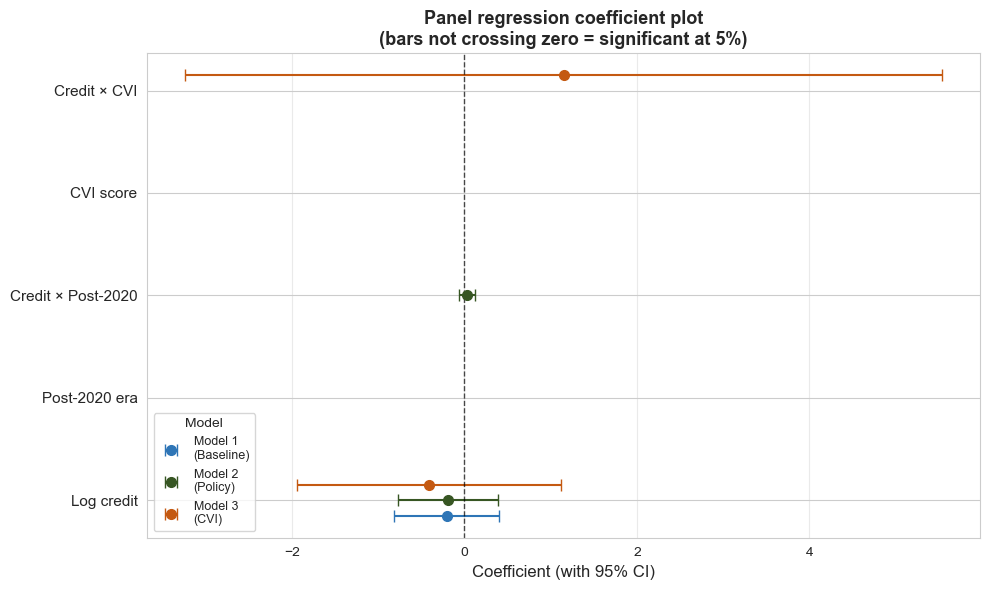

Saved: chart4_coefficient_plot.png


In [21]:
# Coefficient plot: 95% confidence intervals for the key
# regression coefficients across Models 1-3. A bar that does not
# cross zero is statistically significant at the 5% level.

key_vars = ['log_Credit', 'post_2020', 'log_Credit:post_2020',
            'CVI_Score', 'log_Credit:CVI_Score']

fig, ax = plt.subplots(figsize=(10, 6))

models_to_plot = [
    ('Model 1\n(Baseline)',  res1, '#2E75B6'),
    ('Model 2\n(Policy)',    res2, '#375623'),
    ('Model 3\n(CVI)',       res3, '#C45911'),
]
offsets = [-0.15, 0, 0.15]

for (label, res, color), offset in zip(models_to_plot, offsets):
    for i, var in enumerate(key_vars):
        if var in res.params.index:
            coef     = res.params[var]
            ci_lower = res.conf_int().loc[var, 'lower']
            ci_upper = res.conf_int().loc[var, 'upper']
            ax.errorbar(
                coef, i + offset,
                xerr=[[coef - ci_lower], [ci_upper - coef]],
                fmt='o', color=color, markersize=7, capsize=4,
                linewidth=1.5, label=label if i == 0 else ''
            )

ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.set_yticks(range(len(key_vars)))
ax.set_yticklabels(['Log credit', 'Post-2020 era', 'Credit × Post-2020',
                     'CVI score', 'Credit × CVI'], fontsize=11)
ax.set_xlabel('Coefficient (with 95% CI)', fontsize=12)
ax.set_title('Panel regression coefficient plot\n(bars not crossing zero = significant at 5%)',
             fontsize=13, fontweight='bold')
ax.legend(title='Model', fontsize=9)
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('chart4_coefficient_plot.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart4_coefficient_plot.png")

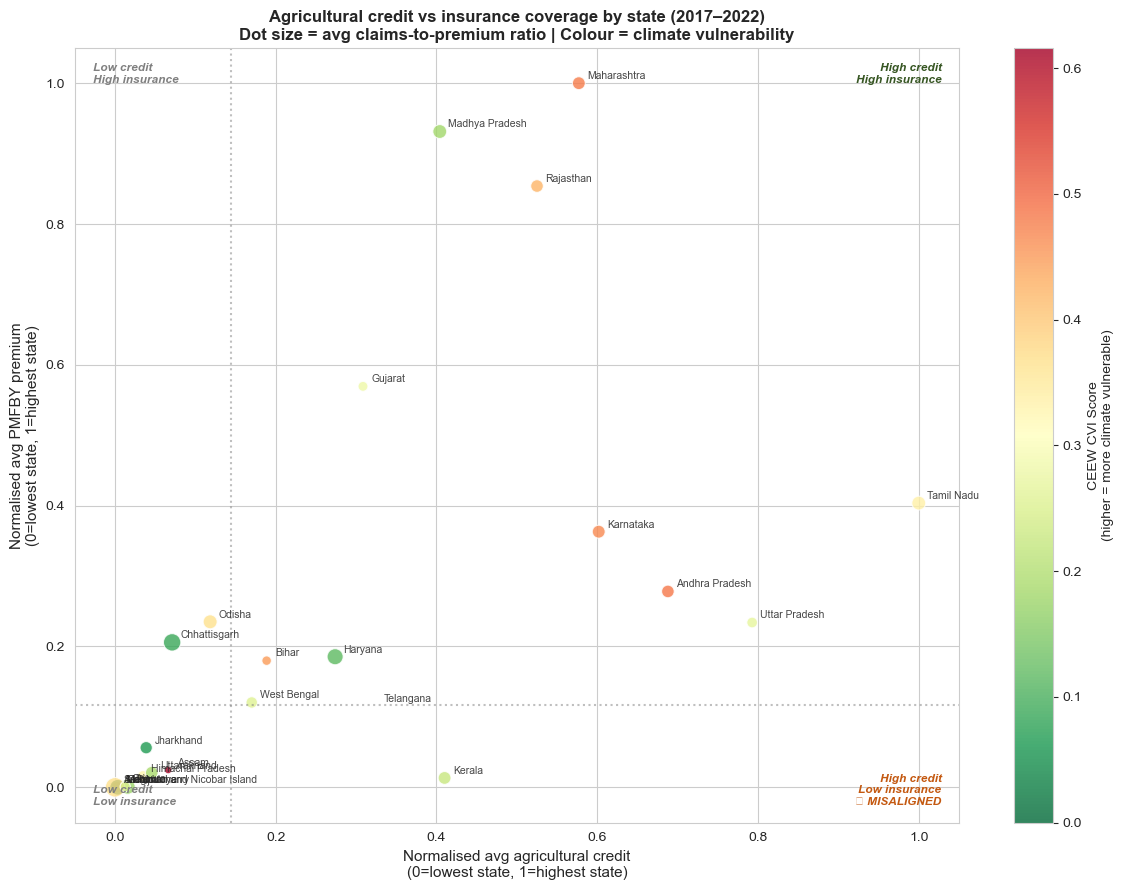

Saved: chart5_misalignment_map.png


In [22]:
# State misalignment map: the most policy-relevant chart.
# Plots normalised average credit against normalised average
# premium per state. Bottom-right quadrant = high credit but
# low insurance ("misaligned" -- farmers borrowing but under-protected).

state_avg = panel.groupby('State').agg(
    Avg_Credit  = ('Credit_Crore',          'mean'),
    Avg_Premium = ('Premium_Crore',         'mean'),
    Avg_CPR     = ('Claims_Premium_Ratio',  'mean'),
    CVI         = ('CVI_Score',             'first')
).reset_index()

for col, new_col in [('Avg_Credit', 'Credit_norm'), ('Avg_Premium', 'Premium_norm')]:
    mn, mx = state_avg[col].min(), state_avg[col].max()
    state_avg[new_col] = (state_avg[col] - mn) / (mx - mn)

state_avg['Misalignment'] = state_avg['Credit_norm'] - state_avg['Premium_norm']

fig, ax = plt.subplots(figsize=(12, 9))

scatter = ax.scatter(
    state_avg['Credit_norm'], state_avg['Premium_norm'],
    c=state_avg['CVI'],                 # colour = CVI score
    s=state_avg['Avg_CPR'] * 120,       # size = claims-to-premium ratio
    cmap='RdYlGn_r', alpha=0.8, edgecolors='white', linewidths=0.8
)
plt.colorbar(scatter, label='CEEW CVI Score\n(higher = more climate vulnerable)')

for _, row in state_avg.iterrows():
    ax.annotate(row['State'], (row['Credit_norm'], row['Premium_norm']),
                textcoords='offset points', xytext=(6, 3),
                fontsize=7.5, alpha=0.85)

ax.axvline(x=state_avg['Credit_norm'].median(), color='grey', linestyle=':', alpha=0.5)
ax.axhline(y=state_avg['Premium_norm'].median(), color='grey', linestyle=':', alpha=0.5)

for x, y, ha, va, text, color in [
    (0.02, 0.98, 'left', 'top', 'Low credit\nHigh insurance', 'grey'),
    (0.98, 0.98, 'right', 'top', 'High credit\nHigh insurance', '#375623'),
    (0.02, 0.02, 'left', 'bottom', 'Low credit\nLow insurance', 'grey'),
    (0.98, 0.02, 'right', 'bottom', 'High credit\nLow insurance\n⚠ MISALIGNED', '#C45911'),
]:
    ax.text(x, y, text, transform=ax.transAxes, fontsize=8.5, va=va, ha=ha,
            color=color, fontweight='bold', style='italic')

ax.set_xlabel('Normalised avg agricultural credit\n(0=lowest state, 1=highest state)', fontsize=11)
ax.set_ylabel('Normalised avg PMFBY premium\n(0=lowest state, 1=highest state)', fontsize=11)
ax.set_title(
    'Agricultural credit vs insurance coverage by state (2017–2022)\n'
    'Dot size = avg claims-to-premium ratio | Colour = climate vulnerability',
    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_misalignment_map.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart5_misalignment_map.png")

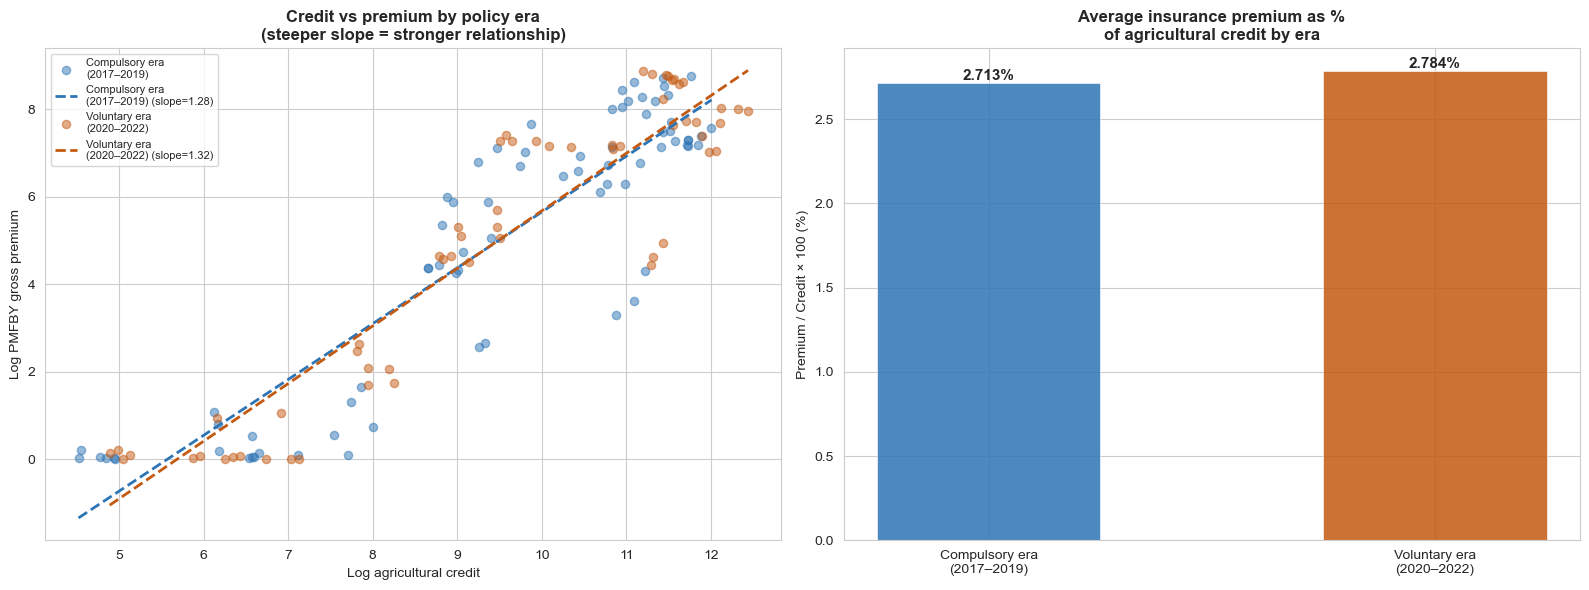

Saved: chart6_era_comparison.png


In [23]:
# Pre- vs post-2020 comparison: visualises the policy-switch
# effect directly by comparing the credit-premium relationship
# across the compulsory (2017-19) and voluntary (2020-22) eras.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

era_labels = {0: 'Compulsory era\n(2017–2019)', 1: 'Voluntary era\n(2020–2022)'}
era_colors = {0: '#2E75B6', 1: '#C45911'}

for era in [0, 1]:
    subset = panel[panel['post_2020'] == era]
    axes[0].scatter(subset['log_Credit'], subset['log_Premium'],
                    alpha=0.5, s=35, color=era_colors[era], label=era_labels[era])
    if len(subset) > 2:
        m, b = np.polyfit(subset['log_Credit'], subset['log_Premium'], 1)
        x_rng = np.linspace(subset['log_Credit'].min(), subset['log_Credit'].max(), 50)
        axes[0].plot(x_rng, m * x_rng + b, color=era_colors[era], linewidth=2,
                     linestyle='--', label=f'{era_labels[era]} (slope={m:.2f})')

axes[0].set_title('Credit vs premium by policy era\n(steeper slope = stronger relationship)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Log agricultural credit')
axes[0].set_ylabel('Log PMFBY gross premium')
axes[0].legend(fontsize=8)

era_stats = panel.groupby('post_2020').agg(
    avg_credit  = ('Credit_Crore',  'mean'),
    avg_premium = ('Premium_Crore', 'mean')
).reset_index()
era_stats['pct'] = era_stats['avg_premium'] / era_stats['avg_credit'] * 100

bars = axes[1].bar(
    [era_labels[e] for e in era_stats['post_2020']], era_stats['pct'],
    color=[era_colors[e] for e in era_stats['post_2020']],
    alpha=0.85, edgecolor='white', linewidth=0.5, width=0.5
)
for bar, val in zip(bars, era_stats['pct']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.3f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_title('Average insurance premium as %\nof agricultural credit by era',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Premium / Credit × 100 (%)')

plt.tight_layout()
plt.savefig('chart6_era_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: chart6_era_comparison.png")